# 00 - Data Cleaning & Feature Engineering

## Preparación y transformación del dataset logístico para Machine Learning

Este notebook prepara el dataset logístico antes de entrenar modelos de Machine Learning.

La etapa se centra en mejorar la calidad de los datos, controlar valores extremos, recalcular variables operacionales y crear nuevas variables con sentido logístico.  
No se analizan predicciones ni resultados de modelos en este notebook; eso se realiza en etapas posteriores.


# Objetivo del notebook

En este notebook voy a:

- cargar el dataset integrado generado por Kedro;
- revisar calidad de datos;
- detectar valores imposibles y valores extremos;
- aplicar una limpieza conservadora;
- controlar outliers mediante clipping;
- recalcular variables derivadas;
- crear nuevas variables de riesgo operacional;
- aplicar transformaciones logarítmicas;
- guardar el dataset final como `dataset_modelo_v3.csv`.

La idea es dejar una base limpia y transformada para los notebooks posteriores.


# Enfoque utilizado

En logística, un valor extremo no siempre es un error.

Una ruta larga, una carga elevada o un vehículo sobreexigido pueden representar operaciones reales y relevantes.  
Por eso, el enfoque de esta limpieza no será eliminar masivamente registros, sino diferenciar entre:

- **errores físicos:** valores imposibles que deben eliminarse;
- **valores extremos:** datos raros que pueden contener información operacional.

Este enfoque permite conservar información útil y preparar mejor el dataset para Machine Learning.


# 1. Configuración inicial

Importo las librerías necesarias y conecto el notebook con Kedro.


In [1]:
# Conexión con Kedro.
%load_ext kedro.ipython

# Librerías principales.
import os
import pandas as pd
import numpy as np

# Visualización.
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


# 2. Carga del dataset base

Cargo el dataset integrado generado previamente en Kedro.

Este dataset contiene información de envíos, rutas, vehículos e incidencias.


In [2]:
df = catalog.load("dataset_modelo")

print("Dimensiones iniciales:", df.shape)

df.head()


[05/13/26 15:41:56] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=10897685;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=10897686;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

Dimensiones iniciales: (1030, 31)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1


## Análisis inicial

El dataset base es el punto de partida del proyecto.  
Antes de entrenar modelos, es necesario revisar su calidad, porque valores extremos o inconsistencias pueden afectar directamente el rendimiento de los algoritmos.


# 3. Revisión de estructura general

Reviso tipos de datos, cantidad de columnas, cantidad de filas y estructura general.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_envio                   1030 non-null   float64
 1   fecha_envio                478 non-null    object 
 2   id_ruta                    1030 non-null   float64
 3   id_vehiculo                1030 non-null   float64
 4   peso_kg                    1030 non-null   float64
 5   volumen_m3                 1030 non-null   float64
 6   tipo_carga                 1030 non-null   object 
 7   estado                     1030 non-null   object 
 8   fecha_entrega              479 non-null    object 
 9   origen                     1002 non-null   object 
 10  destino                    1002 non-null   object 
 11  distancia_km               1002 non-null   float64
 12  tiempo_estimado_hrs        1002 non-null   float64
 13  tipo_via                   1002 non-null   objec

In [4]:
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

df.columns.tolist()


Cantidad de filas: 1030
Cantidad de columnas: 31



[
    'id_envio',
    'fecha_envio',
    'id_ruta',
    'id_vehiculo',
    'peso_kg',
    'volumen_m3',
    'tipo_carga',
    'estado',
    'fecha_entrega',
    'origen',
    'destino',
    'distancia_km',
    'tiempo_estimado_hrs',
    'tipo_via',
    'peaje_total',
    'placa',
    'tipo',
    'capacidad_kg',
    'capacidad_m3',
    'año_fabricacion',
    'estado_vehiculo',
    'km_recorridos',
    'cantidad_incidencias',
    'costo_total_incidencias',
    'tipo_incidencia_principal',
    'tiene_incidencia',
    'dias_entrega',
    'velocidad_promedio_km_h',
    'uso_capacidad_kg',
    'uso_capacidad_m3',
    'entrega_tardia'
]

# 4. Revisión de valores nulos

Reviso los valores nulos del dataset para identificar columnas que puedan requerir tratamiento posterior.


In [5]:
nulos = df.isnull().sum().sort_values(ascending=False)

nulos[nulos > 0]



fecha_envio            552
fecha_entrega          551
año_fabricacion         31
capacidad_m3            31
capacidad_kg            31
tipo                    31
placa                   31
estado_vehiculo         31
km_recorridos           31
peaje_total             28
tiempo_estimado_hrs     28
distancia_km            28
destino                 28
origen                  28
tipo_via                28
dtype: int64

## Análisis de nulos

Los valores nulos no se eliminan automáticamente en esta etapa.

En etapas posteriores de modelado, varios nulos podrán tratarse mediante pipelines de Scikit-learn.  
Sin embargo, esta revisión permite identificar columnas que podrían afectar variables derivadas, especialmente aquellas relacionadas con vehículos, capacidades y fechas.


# 5. Diagnóstico inicial de variables operacionales

Reviso estadísticamente variables relevantes para la operación logística.


In [6]:
variables_revision = [
    "peso_kg",
    "volumen_m3",
    "distancia_km",
    "tiempo_estimado_hrs",
    "velocidad_promedio_km_h",
    "capacidad_kg",
    "capacidad_m3",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "km_recorridos"
]

df[variables_revision].describe().T


,count,mean,std,min,25%,50%,75%,max
peso_kg,1030.0,10887.278544,40728.858673,-66657.5000,3802.350000,7558.600000,11245.375000,724190.000000
volumen_m3,1030.0,30.468417,16.887517,0.1100,16.527500,30.305000,45.090000,59.960000
distancia_km,1002.0,1302.530439,2467.810704,29.6000,507.200000,919.300000,1492.800000,18627.000000
tiempo_estimado_hrs,1002.0,12.299002,6.649828,0.9000,6.300000,12.200000,17.500000,23.700000
velocidad_promedio_km_h,1030.0,166.274662,272.076155,0.0000,39.925764,78.919355,155.914530,1766.555556
capacidad_kg,999.0,7589.589590,5918.089159,1000.0000,3000.000000,5000.000000,10000.000000,20000.000000
capacidad_m3,999.0,36.538739,20.258987,5.3000,18.500000,38.100000,49.200000,78.900000
uso_capacidad_kg,1030.0,3.465193,20.972171,-13.3315,0.420878,1.096690,2.426745,621.785000
uso_capacidad_m3,1030.0,1.243508,1.401316,0.0000,0.413542,0.809654,1.550257,10.871698
km_recorridos,999.0,227408.516517,135214.959340,13823.0000,110804.000000,224573.500000,341278.000000,478395.000000


## Análisis del diagnóstico

El diagnóstico inicial permite observar problemas importantes:

- `peso_kg` contiene valores negativos y valores extremadamente altos;
- `velocidad_promedio_km_h` contiene valores físicamente imposibles para transporte terrestre;
- `distancia_km` presenta rutas extremadamente largas;
- `uso_capacidad_kg` contiene ratios negativos y valores explosivos;
- varias variables presentan escalas muy diferentes.

Estos problemas pueden distorsionar el análisis y afectar el aprendizaje de los modelos.


# 6. Conteo de reglas problemáticas

Cuantifico cuántos registros cumplen condiciones problemáticas.

Esto permite justificar las decisiones de limpieza con evidencia.


In [7]:
condiciones = {
    "peso_kg_menor_igual_cero": df["peso_kg"] <= 0,
    "peso_kg_extremo_mayor_40000": df["peso_kg"] > 40000,
    "distancia_km_menor_igual_cero": df["distancia_km"] <= 0,
    "distancia_km_extrema_mayor_4000": df["distancia_km"] > 4000,
    "tiempo_estimado_menor_igual_cero": df["tiempo_estimado_hrs"] <= 0,
    "velocidad_menor_igual_cero": df["velocidad_promedio_km_h"] <= 0,
    "velocidad_extrema_mayor_180": df["velocidad_promedio_km_h"] > 180,
    "uso_capacidad_kg_negativo": df["uso_capacidad_kg"] < 0,
    "uso_capacidad_kg_mayor_1_5": df["uso_capacidad_kg"] > 1.5,
    "uso_capacidad_m3_mayor_3": df["uso_capacidad_m3"] > 3
}

resumen_reglas = pd.DataFrame({
    "regla": condiciones.keys(),
    "cantidad": [cond.sum() for cond in condiciones.values()]
})

resumen_reglas


,regla,cantidad
0,peso_kg_menor_igual_cero,4
1,peso_kg_extremo_mayor_40000,10
2,distancia_km_menor_igual_cero,0
3,distancia_km_extrema_mayor_4000,19
4,tiempo_estimado_menor_igual_cero,0
5,velocidad_menor_igual_cero,28
6,velocidad_extrema_mayor_180,198
7,uso_capacidad_kg_negativo,4
8,uso_capacidad_kg_mayor_1_5,393
9,uso_capacidad_m3_mayor_3,86


## Análisis de reglas problemáticas

No todas las reglas representan errores.

Por ejemplo, `uso_capacidad_kg > 1.5` puede indicar una operación sobrecargada.  
Eso no necesariamente debe eliminarse, porque podría ser una señal importante de riesgo operacional.

En cambio, valores como peso negativo, distancia menor o igual a cero, tiempo no positivo o velocidad no positiva sí representan errores físicos.


# 7. Visualización inicial de outliers

Visualizo las variables más problemáticas antes de aplicar transformaciones.


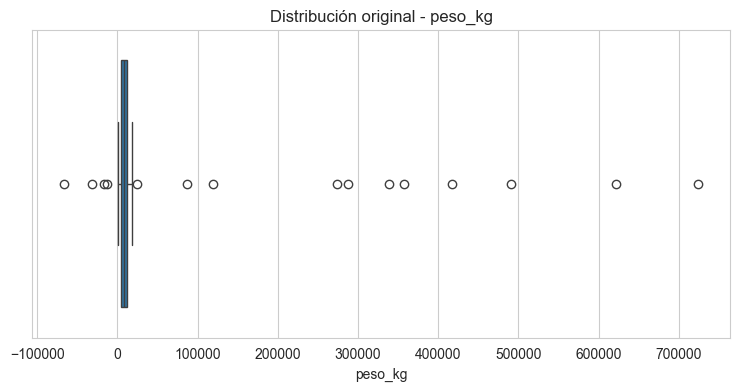

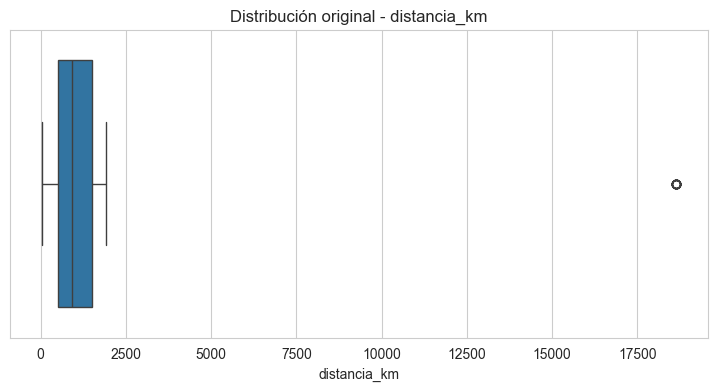

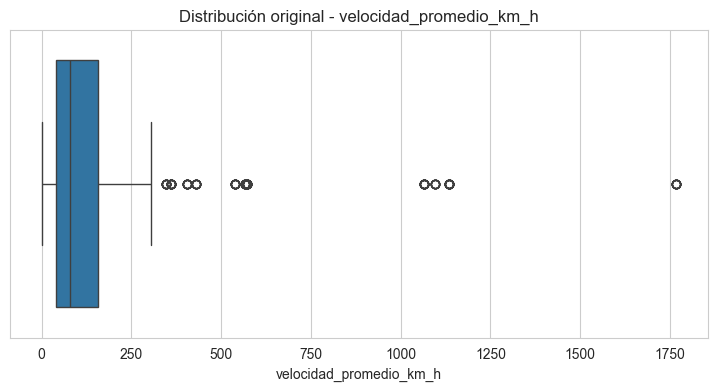

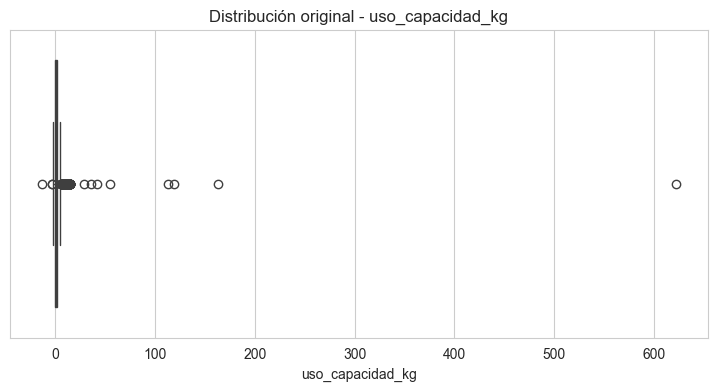

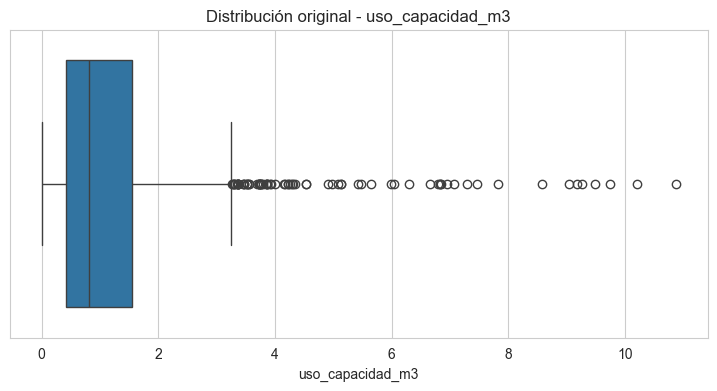

In [8]:
variables_outliers = [
    "peso_kg",
    "distancia_km",
    "velocidad_promedio_km_h",
    "uso_capacidad_kg",
    "uso_capacidad_m3"
]

for col in variables_outliers:
    plt.figure(figsize=(9, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Distribución original - {col}")
    plt.xlabel(col)
    plt.show()


## Análisis visual inicial

Los boxplots muestran que algunas variables están dominadas por valores extremos.

Estos valores comprimen la distribución principal y dificultan la lectura de los datos.  
Por eso se aplicará una estrategia de limpieza conservadora y clipping.


# 8. Limpieza conservadora

Creo una copia del dataset original y elimino únicamente registros con errores físicos claros.


In [9]:
df_v3 = df.copy()

filas_antes = df_v3.shape[0]

df_v3 = df_v3[
    (df_v3["peso_kg"] > 0) &
    (df_v3["distancia_km"] > 0) &
    (df_v3["tiempo_estimado_hrs"] > 0) &
    (df_v3["velocidad_promedio_km_h"] > 0)
].copy()

filas_despues = df_v3.shape[0]

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)
print("Filas eliminadas:", filas_antes - filas_despues)
print("Porcentaje eliminado:", round(((filas_antes - filas_despues) / filas_antes) * 100, 2), "%")


Filas antes: 1030
Filas después: 998
Filas eliminadas: 32
Porcentaje eliminado: 3.11 %


## Análisis de la limpieza conservadora

Esta limpieza conserva casi todo el dataset.

La decisión es importante porque evita perder registros que podrían representar operaciones exigentes, como rutas largas o cargas altas.  
En vez de eliminar masivamente, se eliminan solo valores físicamente inválidos.


# 9. Tratamiento de extremos mediante clipping

Después de eliminar errores físicos, se controlan valores extremos mediante clipping.

El clipping no elimina registros, sino que limita valores superiores a rangos definidos.


In [10]:
# Guardar valores originales para comparación.
df_v3["peso_kg_original"] = df_v3["peso_kg"]
df_v3["distancia_km_original"] = df_v3["distancia_km"]
df_v3["velocidad_promedio_km_h_original"] = df_v3["velocidad_promedio_km_h"]
df_v3["uso_capacidad_kg_original"] = df_v3["uso_capacidad_kg"]
df_v3["uso_capacidad_m3_original"] = df_v3["uso_capacidad_m3"]

# Clipping conservador.
df_v3["peso_kg"] = df_v3["peso_kg"].clip(upper=40000)
df_v3["distancia_km"] = df_v3["distancia_km"].clip(upper=4000)
df_v3["velocidad_promedio_km_h"] = df_v3["velocidad_promedio_km_h"].clip(upper=180)

# En ratios se conserva la sobrecarga, pero se limitan valores explosivos.
df_v3["uso_capacidad_kg"] = df_v3["uso_capacidad_kg"].clip(lower=0, upper=5)
df_v3["uso_capacidad_m3"] = df_v3["uso_capacidad_m3"].clip(lower=0, upper=5)

df_v3[[
    "peso_kg",
    "distancia_km",
    "velocidad_promedio_km_h",
    "uso_capacidad_kg",
    "uso_capacidad_m3"
]].describe().T


,count,mean,std,min,25%,50%,75%,max
peso_kg,998.0,7860.699900,5340.718864,13.600000,3835.475000,7558.600000,11283.750000,40000.0
distancia_km,998.0,1026.657415,674.021421,29.600000,507.200000,919.300000,1492.800000,4000.0
velocidad_promedio_km_h,998.0,92.736315,59.472952,2.943396,40.136842,79.422222,155.914530,180.0
uso_capacidad_kg,998.0,1.707254,1.638906,0.000000,0.442062,1.113280,2.460825,5.0
uso_capacidad_m3,998.0,1.192896,1.144612,0.000000,0.415988,0.813299,1.566036,5.0


## Análisis del clipping

Los límites aplicados buscan controlar valores muy extremos sin eliminar filas completas.

Se limita:

- `peso_kg` a 40.000;
- `distancia_km` a 4.000;
- `velocidad_promedio_km_h` a 180;
- `uso_capacidad_kg` y `uso_capacidad_m3` a 5.

Esto estabiliza las escalas y mantiene información operacional relevante.


# 10. Comparación estadística antes y después

Comparo estadísticas descriptivas del dataset original y la versión V3.


In [11]:
variables_comparacion = [
    "peso_kg",
    "distancia_km",
    "velocidad_promedio_km_h",
    "uso_capacidad_kg",
    "uso_capacidad_m3"
]

comparacion = pd.concat(
    [
        df[variables_comparacion].describe().T.add_suffix("_original"),
        df_v3[variables_comparacion].describe().T.add_suffix("_v3")
    ],
    axis=1
)

comparacion


,count_original,mean_original,std_original,min_original,25%_original,50%_original,75%_original,max_original,count_v3,mean_v3,std_v3,min_v3,25%_v3,50%_v3,75%_v3,max_v3
peso_kg,1030.0,10887.278544,40728.858673,-66657.5000,3802.350000,7558.600000,11245.375000,724190.000000,998.0,7860.699900,5340.718864,13.600000,3835.475000,7558.600000,11283.750000,40000.0
distancia_km,1002.0,1302.530439,2467.810704,29.6000,507.200000,919.300000,1492.800000,18627.000000,998.0,1026.657415,674.021421,29.600000,507.200000,919.300000,1492.800000,4000.0
velocidad_promedio_km_h,1030.0,166.274662,272.076155,0.0000,39.925764,78.919355,155.914530,1766.555556,998.0,92.736315,59.472952,2.943396,40.136842,79.422222,155.914530,180.0
uso_capacidad_kg,1030.0,3.465193,20.972171,-13.3315,0.420878,1.096690,2.426745,621.785000,998.0,1.707254,1.638906,0.000000,0.442062,1.113280,2.460825,5.0
uso_capacidad_m3,1030.0,1.243508,1.401316,0.0000,0.413542,0.809654,1.550257,10.871698,998.0,1.192896,1.144612,0.000000,0.415988,0.813299,1.566036,5.0


## Análisis comparativo

La comparación permite observar una reducción clara de máximos y desviaciones extremas.

Esto indica que el dataset V3 mantiene la variabilidad principal, pero reduce el impacto de valores demasiado explosivos.


# 11. Comparación visual antes y después

Visualizo el efecto del clipping sobre las variables más problemáticas.


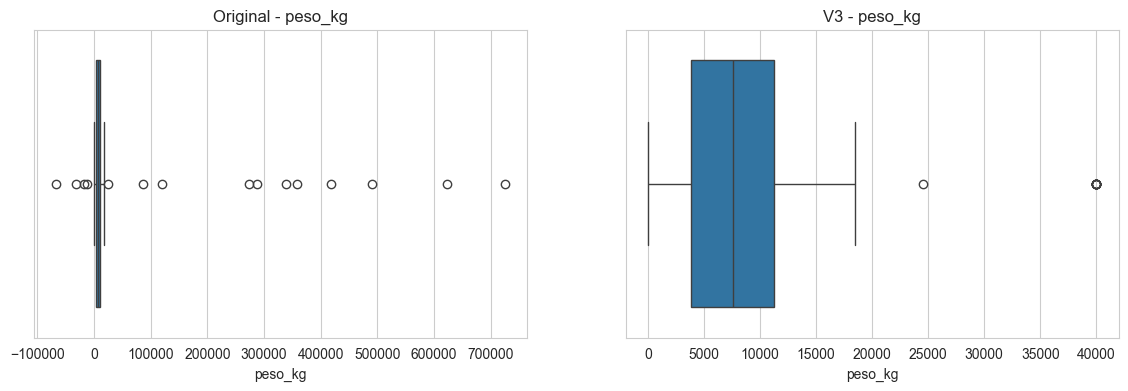

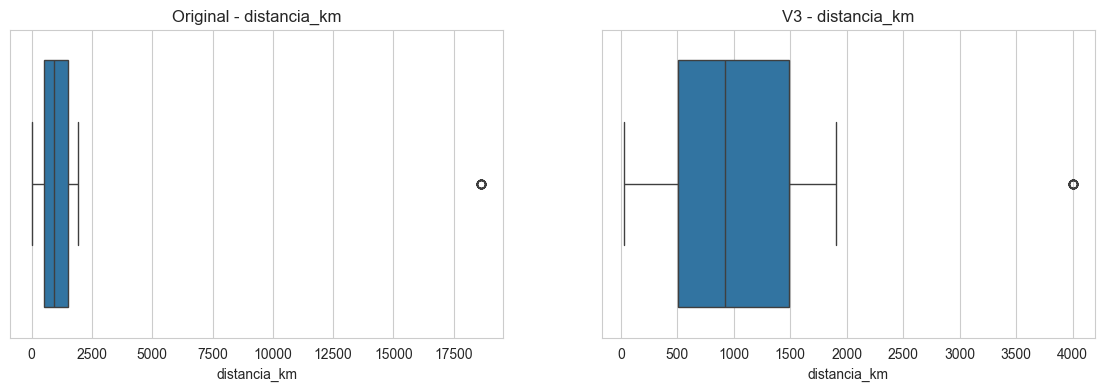

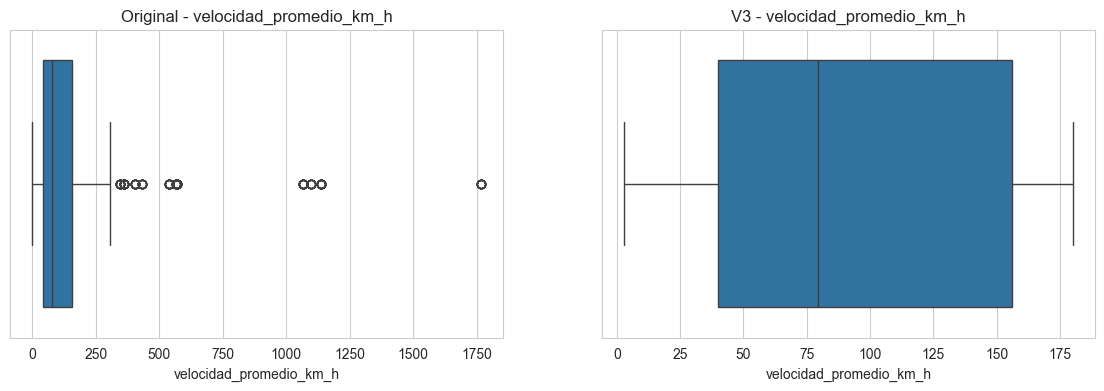

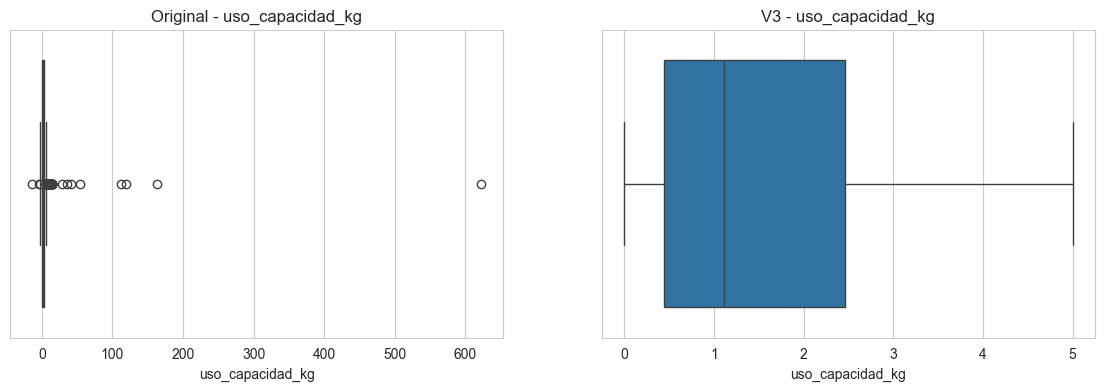

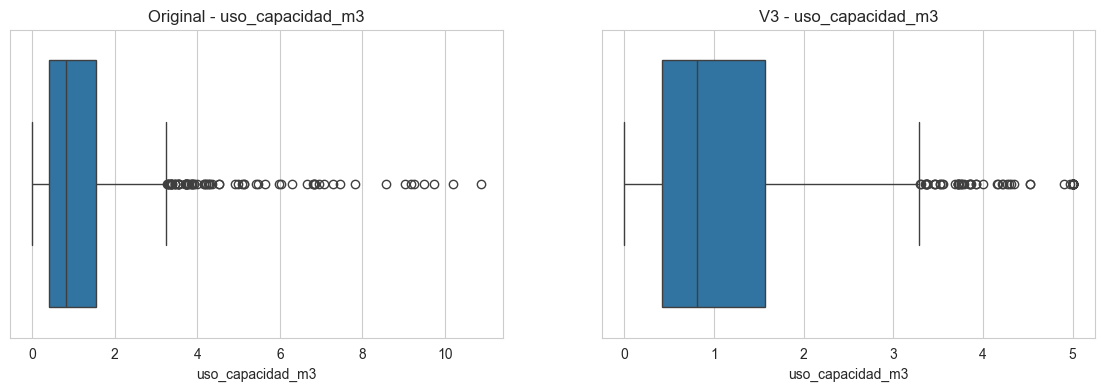

In [12]:
for col in variables_comparacion:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.boxplot(x=df[col], ax=axes[0])
    axes[0].set_title(f"Original - {col}")

    sns.boxplot(x=df_v3[col], ax=axes[1])
    axes[1].set_title(f"V3 - {col}")

    plt.show()


## Análisis de boxplots

Después del clipping, las variables presentan rangos más controlados.

La versión V3 permite visualizar mejor la distribución principal de los datos y reduce el peso de valores extremos que antes dominaban la escala.


# 12. Recalculo de variables de capacidad

Después del clipping, recalculo ratios de uso de capacidad para que se basen en valores tratados.


In [13]:
df_v3["uso_capacidad_kg_recalculado"] = (
    df_v3["peso_kg"] / df_v3["capacidad_kg"]
)

df_v3["uso_capacidad_m3_recalculado"] = (
    df_v3["volumen_m3"] / df_v3["capacidad_m3"]
)

df_v3["uso_capacidad_kg_recalculado"] = (
    df_v3["uso_capacidad_kg_recalculado"].clip(lower=0, upper=5)
)

df_v3["uso_capacidad_m3_recalculado"] = (
    df_v3["uso_capacidad_m3_recalculado"].clip(lower=0, upper=5)
)

df_v3[[
    "uso_capacidad_kg",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3",
    "uso_capacidad_m3_recalculado"
]].describe().T


,count,mean,std,min,25%,50%,75%,max
uso_capacidad_kg,998.0,1.707254,1.638906,0.000000,0.442062,1.113280,2.460825,5.0
uso_capacidad_kg_recalculado,971.0,1.747518,1.626008,0.002410,0.498960,1.176100,2.510443,5.0
uso_capacidad_m3,998.0,1.192896,1.144612,0.000000,0.415988,0.813299,1.566036,5.0
uso_capacidad_m3_recalculado,971.0,1.226066,1.142757,0.001401,0.449641,0.836199,1.616188,5.0


## Análisis de ratios recalculados

Los ratios recalculados permiten representar mejor la exigencia real del vehículo después de tratar pesos y capacidades.

Estas variables serán útiles para representar sobrecarga y presión operacional.


# 13. Feature Engineering operacional

Creo nuevas variables con sentido logístico.

Estas variables buscan representar conceptos como exigencia del vehículo, sobrecarga, riesgo por velocidad y complejidad operacional.


In [14]:
anio_referencia = 2026

df_v3["antiguedad_vehiculo"] = anio_referencia - df_v3["año_fabricacion"]

df_v3["densidad_carga"] = (
    df_v3["peso_kg"] / (df_v3["volumen_m3"] + 0.001)
)

df_v3["riesgo_operacional"] = (
    df_v3["distancia_km"] * df_v3["uso_capacidad_kg_recalculado"]
)

df_v3["riesgo_velocidad"] = (
    df_v3["distancia_km"] * df_v3["velocidad_promedio_km_h"]
)

df_v3["vehiculo_exigido"] = np.where(
    df_v3["uso_capacidad_kg_recalculado"] >= 0.90,
    1,
    0
)

df_v3["sobrecarga_kg"] = np.where(
    df_v3["uso_capacidad_kg_recalculado"] > 1,
    1,
    0
)

umbral_ruta_larga = df_v3["distancia_km"].quantile(0.75)

df_v3["ruta_larga"] = np.where(
    df_v3["distancia_km"] >= umbral_ruta_larga,
    1,
    0
)

df_v3["velocidad_alta"] = np.where(
    df_v3["velocidad_promedio_km_h"] >= 100,
    1,
    0
)

df_v3["vehiculo_riesgoso_estado"] = np.where(
    df_v3["estado_vehiculo"].isin(["en mantención", "fuera de servicio"]),
    1,
    0
)

df_v3["via_compleja"] = np.where(
    df_v3["tipo_via"].isin(["camino rural", "ruta nacional"]),
    1,
    0
)

print("Variables derivadas creadas correctamente.")
print("Umbral ruta larga:", umbral_ruta_larga)


Variables derivadas creadas correctamente.
Umbral ruta larga: 1492.8


## Interpretación de variables derivadas

Las nuevas variables permiten representar aspectos logísticos más útiles para Machine Learning:

- `densidad_carga`: relación entre peso y volumen;
- `riesgo_operacional`: combinación entre distancia y uso de capacidad;
- `riesgo_velocidad`: exposición asociada a velocidad y distancia;
- `vehiculo_exigido`: identifica vehículos cerca del límite;
- `sobrecarga_kg`: marca exceso de carga;
- `ruta_larga`: identifica rutas extensas;
- `velocidad_alta`: marca velocidades elevadas;
- `vehiculo_riesgoso_estado`: identifica estados vehiculares críticos;
- `via_compleja`: identifica vías potencialmente más exigentes.


# 14. Revisión de variables derivadas

Reviso las nuevas variables creadas para entender sus rangos y distribución.


In [15]:
variables_derivadas = [
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_operacional",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja"
]

df_v3[variables_derivadas].describe().T


,count,mean,std,min,25%,50%,75%,max
antiguedad_vehiculo,971.0,7.894954,3.805759,2.000000,4.000000,8.000000,10.000000,16.000000
densidad_carga,998.0,977.773601,4783.609254,0.545506,130.680924,248.924508,466.696608,81144.144144
riesgo_operacional,971.0,1832.021294,2479.975768,0.355957,348.299907,925.223706,2279.954104,20000.000000
riesgo_velocidad,998.0,119599.770365,126992.403801,91.833962,30397.719481,71619.702542,192456.000000,720000.000000
vehiculo_exigido,998.0,0.563126,0.496248,0.000000,0.000000,1.000000,1.000000,1.000000
sobrecarga_kg,998.0,0.529058,0.499405,0.000000,0.000000,1.000000,1.000000,1.000000
ruta_larga,998.0,0.258517,0.438039,0.000000,0.000000,0.000000,1.000000,1.000000
velocidad_alta,998.0,0.378758,0.485321,0.000000,0.000000,0.000000,1.000000,1.000000
vehiculo_riesgoso_estado,998.0,0.292585,0.455178,0.000000,0.000000,0.000000,1.000000,1.000000
via_compleja,998.0,0.333667,0.471759,0.000000,0.000000,0.000000,1.000000,1.000000


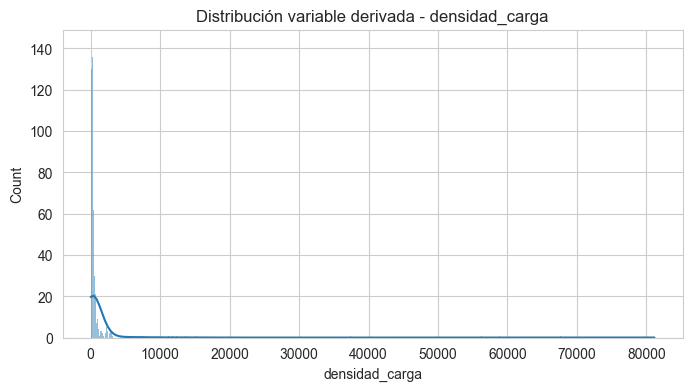

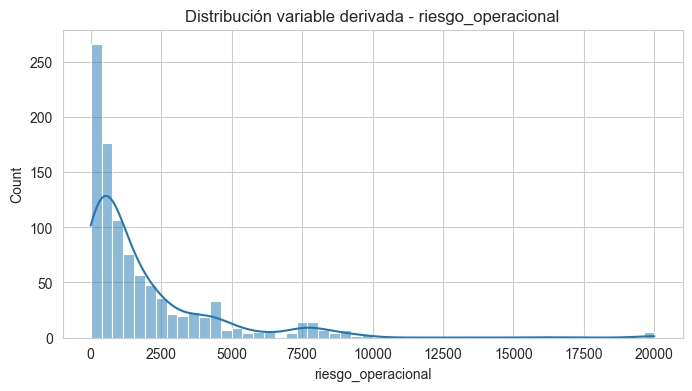

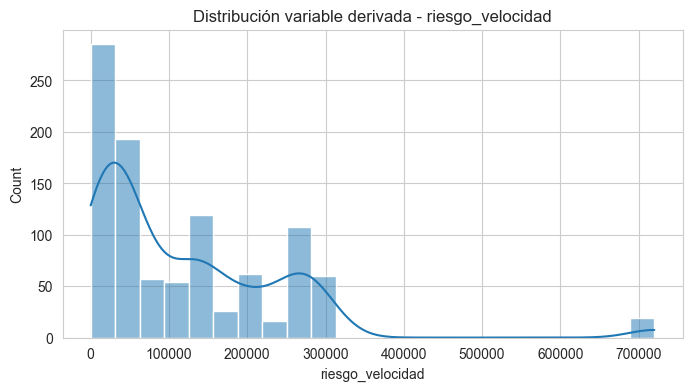

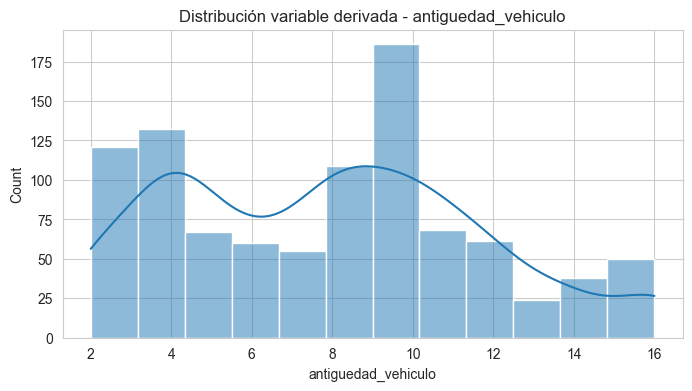

In [16]:
for col in ["densidad_carga", "riesgo_operacional", "riesgo_velocidad", "antiguedad_vehiculo"]:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_v3[col], kde=True)
    plt.title(f"Distribución variable derivada - {col}")
    plt.xlabel(col)
    plt.show()


## Análisis de variables derivadas

Algunas variables derivadas muestran asimetría positiva.  
Esto es normal en métricas de riesgo, carga y operación, ya que la mayoría de envíos puede concentrarse en rangos moderados mientras algunos casos presentan exigencias mucho mayores.

Para reducir esta asimetría se aplicarán transformaciones logarítmicas.


# 15. Transformaciones logarítmicas

Aplico `log1p` a variables positivas y sesgadas.

Esta transformación reduce la influencia de valores muy altos sin alterar el orden relativo de los datos.


In [17]:
variables_log = [
    "peso_kg",
    "distancia_km",
    "volumen_m3",
    "velocidad_promedio_km_h",
    "densidad_carga",
    "riesgo_operacional",
    "riesgo_velocidad",
    "km_recorridos"
]

for col in variables_log:
    nueva_col = col + "_log"
    df_v3[nueva_col] = np.log1p(df_v3[col].clip(lower=0))

df_v3[[col + "_log" for col in variables_log]].describe().T


,count,mean,std,min,25%,50%,75%,max
peso_kg_log,998.0,8.655609,0.986986,2.681022,8.252287,8.930574,9.331208,10.596660
distancia_km_log,998.0,6.654640,0.897665,3.421000,6.230875,6.824700,7.309078,8.294300
volumen_m3_log,998.0,3.210752,0.823222,0.104360,2.865339,3.443778,3.830596,4.110218
velocidad_promedio_km_h_log,998.0,4.244859,0.890656,1.372042,3.716904,4.387291,5.055701,5.198497
densidad_carga_log,998.0,5.534815,1.366099,0.435351,4.880377,5.521158,6.147818,11.303995
riesgo_operacional_log,971.0,6.656960,1.535510,0.304507,5.855931,6.831116,7.732349,9.903538
riesgo_velocidad_log,998.0,10.871917,1.735348,4.530813,10.322156,11.179139,12.167626,13.487008
km_recorridos_log,971.0,12.071901,0.835071,9.534161,11.615527,12.321963,12.740456,13.078194


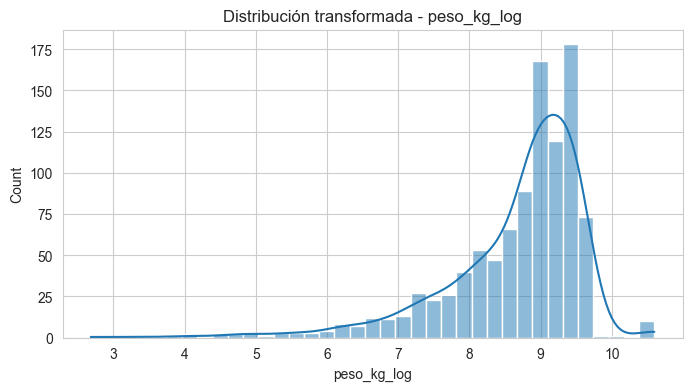

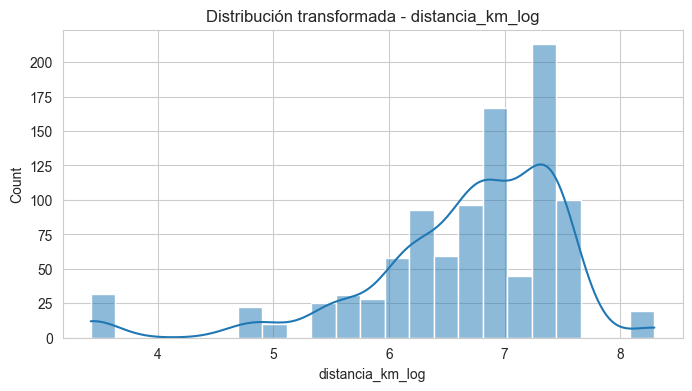

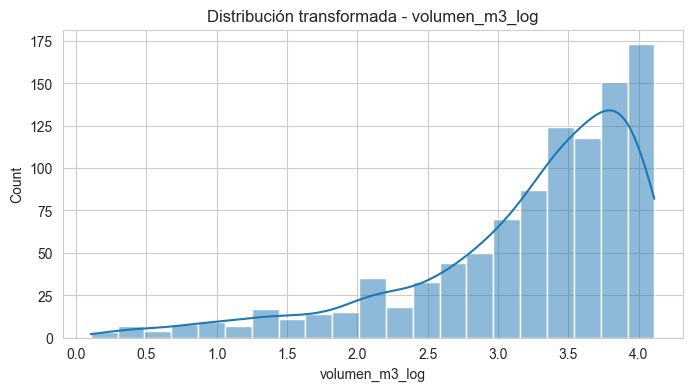

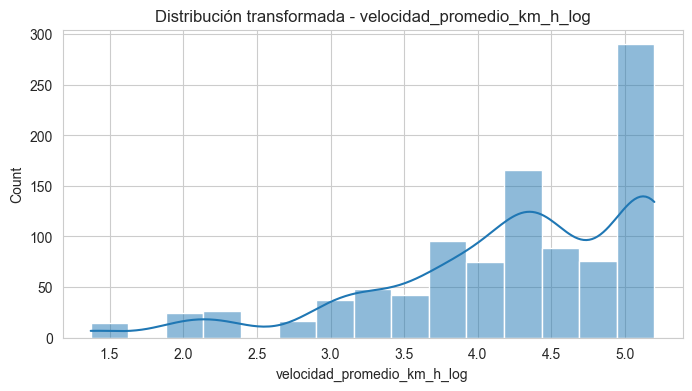

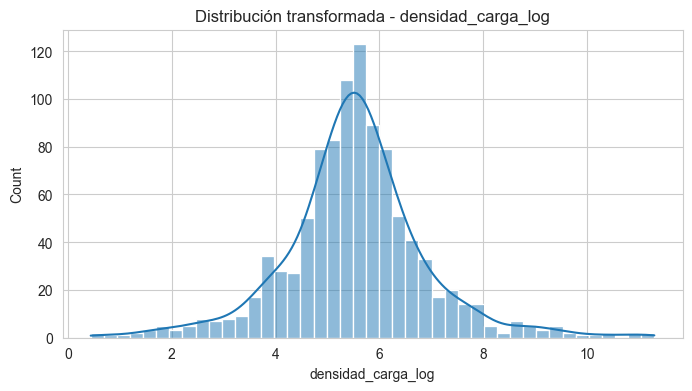

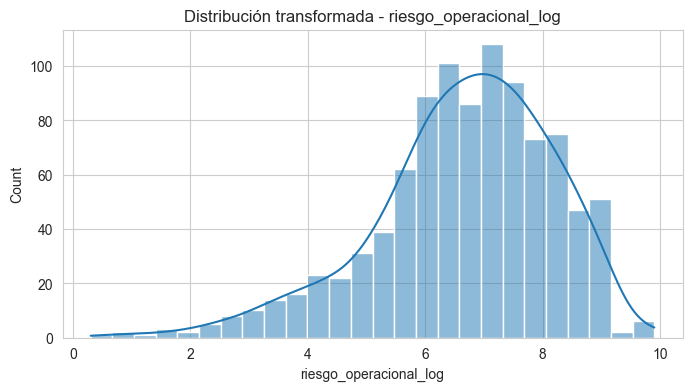

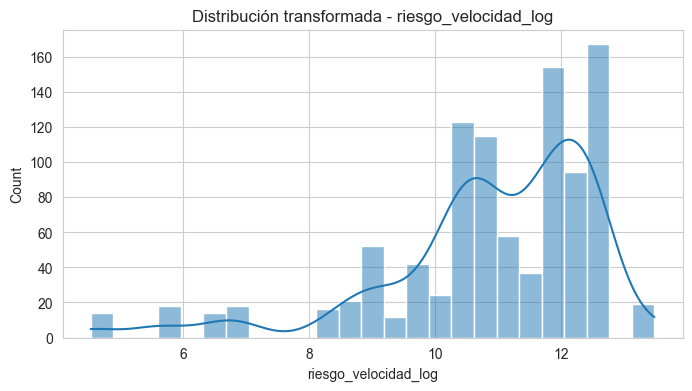

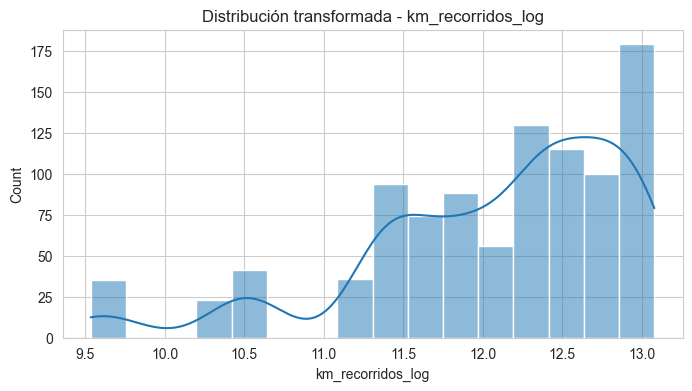

In [18]:
for col in [col + "_log" for col in variables_log]:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_v3[col], kde=True)
    plt.title(f"Distribución transformada - {col}")
    plt.xlabel(col)
    plt.show()


## Análisis de transformaciones logarítmicas

Las variables transformadas quedan en escalas más estables.

Esto puede facilitar el entrenamiento de modelos, especialmente aquellos sensibles a diferencias de magnitud entre variables.


# 16. Revisión final de nulos e infinitos

Verifico que las transformaciones no hayan generado infinitos y reviso nulos restantes.


In [19]:
nulos_v3 = df_v3.isnull().sum().sort_values(ascending=False)

print("Columnas con nulos:")
display(nulos_v3[nulos_v3 > 0])

numericas_v3 = df_v3.select_dtypes(include=np.number)
infinitos_v3 = np.isinf(numericas_v3).sum()

print("\nColumnas con infinitos:")
display(infinitos_v3[infinitos_v3 > 0])


Columnas con nulos:



fecha_envio                     537
fecha_entrega                   535
capacidad_m3                     27
capacidad_kg                     27
estado_vehiculo                  27
km_recorridos                    27
placa                            27
año_fabricacion                  27
tipo                             27
uso_capacidad_m3_recalculado     27
riesgo_operacional_log           27
km_recorridos_log                27
riesgo_operacional               27
antiguedad_vehiculo              27
uso_capacidad_kg_recalculado     27
dtype: int64


Columnas con infinitos:


Series([], dtype: int64)

## Análisis final de calidad

No deberían existir valores infinitos después de las transformaciones.

Los nulos restantes se podrán tratar en los notebooks de modelado mediante pipelines de imputación, evitando eliminar más registros de forma innecesaria.


# 17. Comparación final del dataset original vs V3

Reviso el cambio final en dimensiones después del proceso de limpieza y transformación.


In [20]:
print("Dataset original:", df.shape)
print("Dataset V3:", df_v3.shape)

filas_eliminadas = df.shape[0] - df_v3.shape[0]
porcentaje_eliminado = round((filas_eliminadas / df.shape[0]) * 100, 2)

print("Filas eliminadas:", filas_eliminadas)
print("Porcentaje eliminado:", porcentaje_eliminado, "%")


Dataset original: (1030, 31)
Dataset V3: (998, 56)
Filas eliminadas: 32
Porcentaje eliminado: 3.11 %


## Análisis final de dimensiones

El dataset V3 conserva la mayor parte de los registros originales.

Esto confirma que la limpieza fue conservadora y que el objetivo principal fue mejorar la calidad sin destruir información útil para el aprendizaje.


# 18. Variables recomendadas para modelado

Defino una lista de variables candidatas para los notebooks posteriores.

La selección final dependerá del objetivo específico de cada modelo.


In [21]:
variables_modelo_v3 = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_operacional",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja",
    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_operacional_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

variables_modelo_v3 = [col for col in variables_modelo_v3 if col in df_v3.columns]

print("Cantidad de variables recomendadas:", len(variables_modelo_v3))
variables_modelo_v3


Cantidad de variables recomendadas: 34



[
    'distancia_km',
    'tiempo_estimado_hrs',
    'peso_kg',
    'volumen_m3',
    'capacidad_kg',
    'capacidad_m3',
    'velocidad_promedio_km_h',
    'km_recorridos',
    'tipo_via',
    'tipo_carga',
    'estado_vehiculo',
    'tipo',
    'uso_capacidad_kg',
    'uso_capacidad_m3',
    'uso_capacidad_kg_recalculado',
    'uso_capacidad_m3_recalculado',
    'antiguedad_vehiculo',
    'densidad_carga',
    'riesgo_operacional',
    'riesgo_velocidad',
    'vehiculo_exigido',
    'sobrecarga_kg',
    'ruta_larga',
    'velocidad_alta',
    'vehiculo_riesgoso_estado',
    'via_compleja',
    'peso_kg_log',
    'distancia_km_log',
    'volumen_m3_log',
    'velocidad_promedio_km_h_log',
    'densidad_carga_log',
    'riesgo_operacional_log',
    'riesgo_velocidad_log',
    'km_recorridos_log'
]

## Nota sobre fuga de información

Este notebook solo prepara el dataset.

En los notebooks de modelado se deberá evitar usar variables que generen fuga de información según el objetivo del modelo.  
Por ejemplo, si se predicen incidencias, no deberían utilizarse variables que se conocen solo después de ocurrida la incidencia.


# 19. Vista final del dataset preparado

Reviso una muestra del dataset final antes de guardarlo.


In [22]:
df_v3.head()


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia,peso_kg_original,distancia_km_original,velocidad_promedio_km_h_original,uso_capacidad_kg_original,uso_capacidad_m3_original,uso_capacidad_kg_recalculado,uso_capacidad_m3_recalculado,antiguedad_vehiculo,densidad_carga,riesgo_operacional,riesgo_velocidad,vehiculo_exigido,sobrecarga_kg,ruta_larga,velocidad_alta,vehiculo_riesgoso_estado,via_compleja,peso_kg_log,distancia_km_log,volumen_m3_log,velocidad_promedio_km_h_log,densidad_carga_log,riesgo_operacional_log,riesgo_velocidad_log,km_recorridos_log
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1,12675.8,919.3,55.047904,1.26758,1.389268,1.26758,1.389268,4.0,445.061620,1165.286294,50605.538323,1,1,0,0,1,0,9.447529,6.824700,3.383712,4.026207,6.100457,7.061580,10.831836,9.743554
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1,13.6,679.6,36.934783,0.01360,1.128054,0.01360,1.128054,16.0,0.545506,9.242560,25100.878261,0,0,0,0,0,0,2.681022,6.522975,3.255401,3.635868,0.435351,2.326552,10.130698,11.385149
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1,2536.0,468.4,90.076923,0.12680,1.299486,0.12680,1.299486,3.0,50.167158,59.393120,42192.030769,0,0,0,0,1,1,7.838738,6.151455,3.942552,4.511704,3.935098,4.100875,10.650010,12.403718
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1,466.0,1642.4,86.899471,0.46600,0.548617,0.46600,0.548617,11.0,33.571068,765.358400,142723.691005,0,0,1,0,0,1,6.146329,7.404523,2.700018,4.476194,3.543017,6.641650,11.868673,12.321963
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1,4928.9,1556.6,86.960894,0.98578,0.008961,0.98578,0.008961,3.0,11176.643991,1534.465148,135363.327374,1,0,1,0,0,0,8.503074,7.350901,0.364643,4.476892,9.321671,7.336589,11.815725,11.836891


# 20. Guardado del dataset V3

Guardo el dataset transformado en la carpeta `data/05_model_input`.

Este archivo será la base para los notebooks posteriores.


In [23]:
os.makedirs("data/05_model_input", exist_ok=True)

ruta_salida = "data/05_model_input/dataset_modelo_v3.csv"

df_v3.to_csv(ruta_salida, index=False, encoding="utf-8")

print("Dataset V3 guardado correctamente en:")
print(ruta_salida)


Dataset V3 guardado correctamente en:
data/05_model_input/dataset_modelo_v3.csv


# 21. Conclusiones del notebook

En este notebook se preparó una versión mejorada del dataset logístico.

Las principales decisiones fueron:

- eliminar solo valores físicamente imposibles;
- evitar una limpieza demasiado agresiva;
- controlar valores extremos mediante clipping;
- recalcular ratios de capacidad;
- crear variables operacionales interpretables;
- aplicar transformaciones logarítmicas;
- conservar la mayor cantidad posible de registros.

El resultado final es `dataset_modelo_v3.csv`, una base más estable y preparada para las etapas de análisis, modelado supervisado, optimización y aprendizaje no supervisado.
